In [90]:
import numpy as np
import matplotlib.pyplot as plt
import skimage
import os
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pickle
import pandas as pd
import glob
from run import OUTPUT_DIR
from run import QUEUE

In [91]:
print(OUTPUT_DIR)
print(QUEUE)

GSS
[('mnist', {'p': [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 0.9], 'T': [5], 'learning_rate': [0.001], 'batch_size': [50], 'num_centroids': [4], 'model_training_epoch': [50], 'early_stopping_threshold': [100000], 'random_seed': range(0, 5), 'class_balanced': [True], 'execute_early_stopping': [False]}), ('cifar10', {'p': [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 0.9], 'T': [5], 'learning_rate': [0.001], 'batch_size': [50], 'num_centroids': [4], 'model_training_epoch': [50], 'early_stopping_threshold': [1000000], 'random_seed': range(0, 5), 'class_balanced': [True], 'execute_early_stopping': [False]})]


In [92]:
#choose parameters to graph
OUTPUT_DIR = 'mnist_no_early_stopping'
task_no = 0 # this is the task that the accuracy graph will be displayed for
params = {'exp_name' : ['mnist'], 'early_stopping_threshold': [100000]} # parameters to display


In [93]:

def load_results():
    results = []
    for fname in glob.glob(f'{OUTPUT_DIR}/*/*'):
        # print('Reading from {}'.format(fname))
        if os.path.splitext(fname)[1] == '.pickle':  # Only try to unpickle .pickle files
            try:
                with open(fname, 'rb') as f:
                    result = pickle.load(f)
                    results.append(result)
            except (pickle.UnpicklingError, EOFError, AttributeError) as e:
                print(f"Error unpickling {fname}: {str(e)}")
        # else:
        #     print(f"Skipping non-pickle file: {fname}")
    
    df = pd.DataFrame(results)
    return df

results = load_results()

for param, values in params.items():
    results = results[results[param].isin(values)]
results = results.reset_index(drop=True)


In [94]:

def get_metric(df, p_val, method, metric):
    #returns the average and std for a given metric 
    p_value_df = df[df["p"] == p_val].reset_index(drop=True)
    method_metrics = p_value_df[method]
    metric_values = []
    for i in range(0, len(method_metrics)):         
         if metric == "Accuracy":
            metric_values.append(method_metrics[i]['M3 per task performance'][task_no])

         if metric == "M2 similarity":
             metric_values.append(method_metrics[i]['gradient similarities']['M2'])

         if metric == "M1 similarity":
             metric_values.append(method_metrics[i]['gradient similarities']['M1'])
             
    return metric_values

def get_metric_stats(metric_values):
    return np.average(metric_values), np.std(metric_values)

In [100]:
def aggregate_results(results):
    # Convert to list if it's an Index object
    colnames = results.columns
    colnames_list = colnames.tolist()

    try:
        # First, try to find 'execution_time'
        execution_time_index = colnames_list.index('execution_time')
    except ValueError:
        try:
            # If 'execution_time' is not found, look for 'p'
            execution_time_index = colnames_list.index('p')
        except ValueError:
            # If neither is found, use all column names
            execution_time_index = len(colnames_list)

    methods = colnames_list[:execution_time_index]
    method_names = methods

    unique_p_values = results['p'].unique()
    
    metrics = ["Accuracy", "M1 similarity", "M2 similarity"]
    
    unique_p_values = results['p'].unique()
    
    processed_data = []
    
    for p in unique_p_values:
        for method, method_name in zip(methods, method_names):
            filtered_data = results[(results['p'] == p) & (results[method].notna())]
            
            if not filtered_data.empty:
                row_data = {
                    'p': p,
                    'method': method_name,
                    'samples': len(filtered_data)
                }
                
                for metric in metrics:
                    metric_values = get_metric(filtered_data, p, method, metric)
                    avg, std = get_metric_stats(metric_values)
                    
                    if metric == "Accuracy":
                        row_data['M3_task_avg'] = avg
                        row_data['M3_task_std'] = std
                    elif metric == "M1 similarity":
                        row_data['M1_grad_sim_avg'] = avg
                        row_data['M1_grad_sim_std'] = std
                    elif metric == "M2 similarity":
                        row_data['M2_grad_sim_avg'] = avg
                        row_data['M2_grad_sim_std'] = std
                
                processed_data.append(row_data)
    
    processed_df = pd.DataFrame(processed_data)
    
    return processed_df

In [101]:
aggregated_results = aggregate_results(results)
aggregated_results

,p,method,samples,M3_task_avg,M3_task_std,M1_grad_sim_avg,M1_grad_sim_std,M2_grad_sim_avg,M2_grad_sim_std
0,0.100,RandomMemorySetManager memory selection,5,0.932009,0.042839,0.961856,0.011373,0.970670,0.008867
1,0.100,KMeansMemorySetManager memory selection,5,0.836596,0.030411,0.991399,0.003565,0.996378,0.000528
2,0.100,LambdaMemorySetManager memory selection,5,0.911395,0.070315,0.999628,0.000149,0.999406,0.000167
3,0.100,iCaRL memory selection (icarl),5,0.942790,0.015832,0.999793,0.000098,0.999713,0.000118
4,0.100,iCaRL memory selection (replay),5,0.956501,0.009804,0.999896,0.000053,0.999855,0.000049
5,0.500,RandomMemorySetManager memory selection,5,0.972199,0.012255,0.987116,0.009619,0.995195,0.000770
6,0.500,KMeansMemorySetManager memory selection,5,0.946572,0.004486,0.997537,0.001947,0.999156,0.000209
7,0.500,LambdaMemorySetManager memory selection,5,0.982506,0.003967,0.999815,0.000143,0.999878,0.000073
8,0.500,iCaRL memory selection (icarl),5,0.978723,0.005837,0.999892,0.000111,0.999950,0.000016
9,0.500,iCaRL memory selection (replay),5,0.979480,0.005663,0.999944,0.000055,0.999971,0.000012


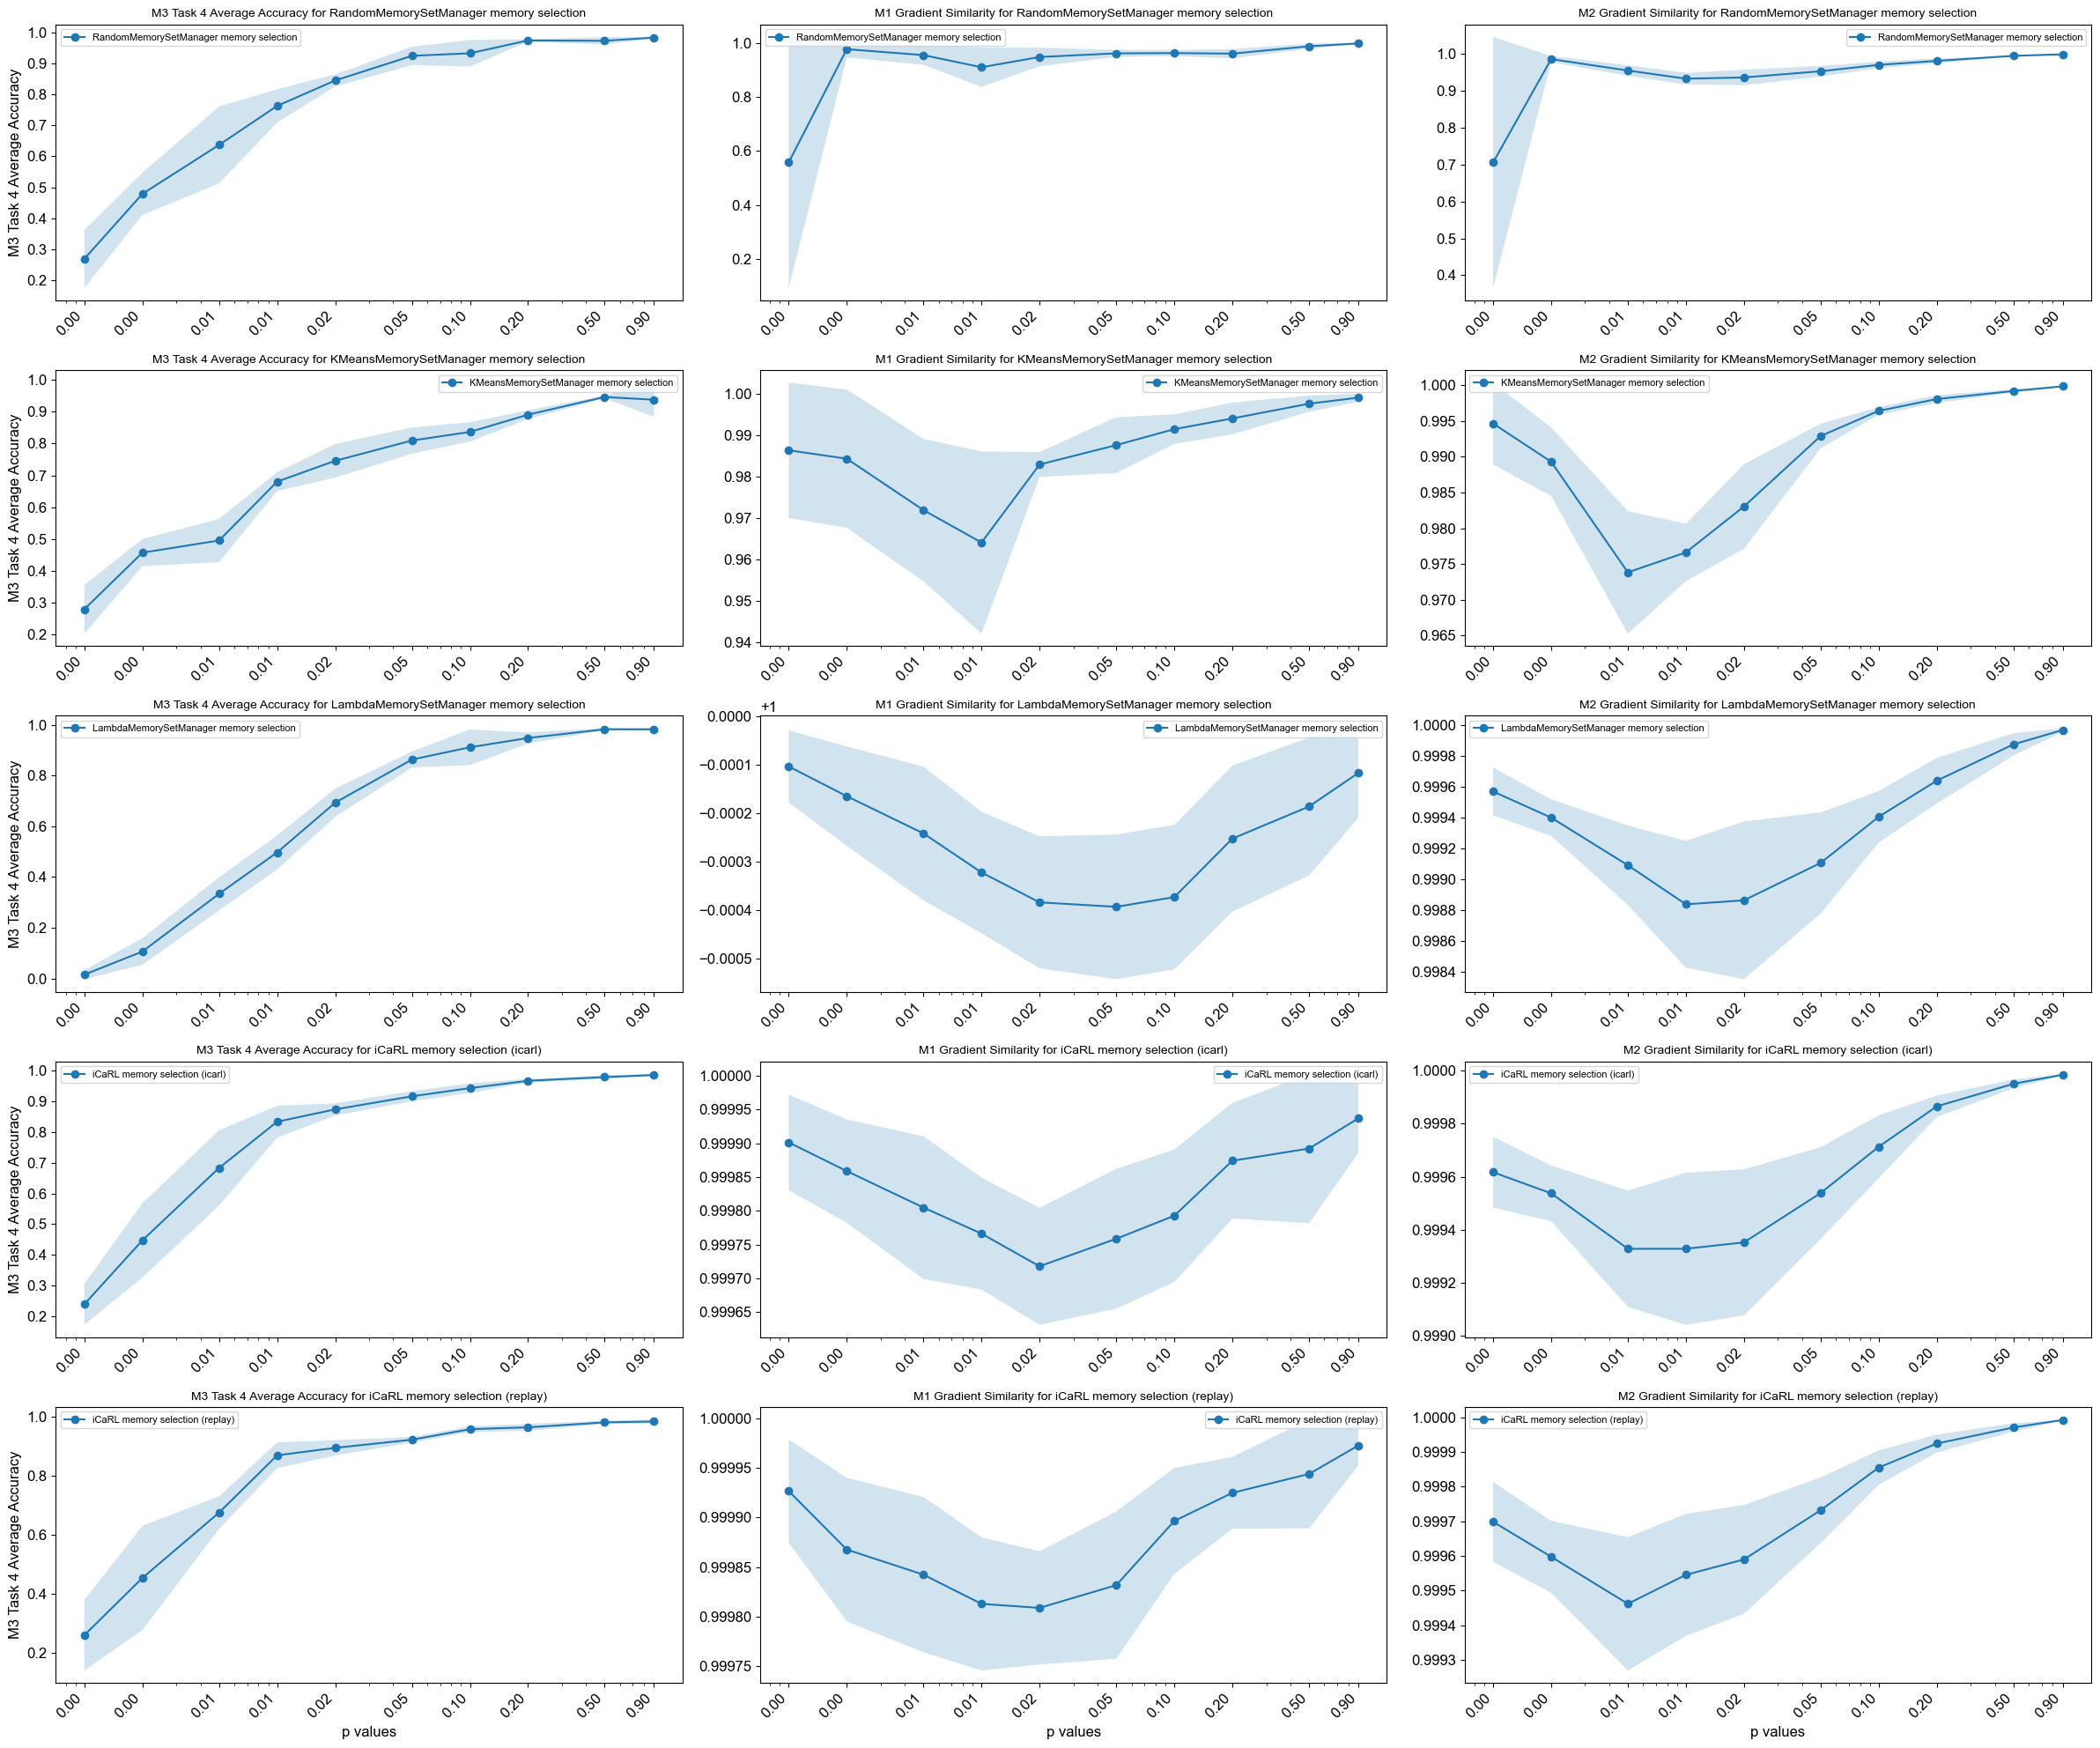

In [97]:

def plot_all_metrics(aggregated_results, dataset_name):
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 12
    
    result_dir = f'gradient_similarity/{dataset_name}/plots'
    if not os.path.exists(result_dir):
        os.makedirs(result_dir)
    
    methods = aggregated_results['method'].unique()
    p_vals = sorted(aggregated_results['p'].unique())
    
    num_methods = len(methods)
    fig, axs = plt.subplots(num_methods, 3, figsize=(24, 4*num_methods))
    
    metrics = ['M3_task', 'M1_grad_sim', 'M2_grad_sim']
    titles = ['M3 Task 4 Average Accuracy', 'M1 Gradient Similarity', 'M2 Gradient Similarity']
    
    for method_index, method in enumerate(methods):
        method_data = aggregated_results[aggregated_results['method'] == method]
        
        for col, (metric, title) in enumerate(zip(metrics, titles)):
            if num_methods == 1:
                ax = axs[col]
            else:
                ax = axs[method_index, col]
            
            avg_values = [method_data[method_data['p'] == p][f'{metric}_avg'].values[0] for p in p_vals]
            std_values = [method_data[method_data['p'] == p][f'{metric}_std'].values[0] for p in p_vals]
            
            ax.plot(p_vals, avg_values, marker='o', label=method)
            ax.fill_between(p_vals, 
                            np.array(avg_values) - np.array(std_values), 
                            np.array(avg_values) + np.array(std_values), 
                            alpha=0.2)
            
            ax.set_xscale('log')
            ax.set_title(f'{title} for {method}', fontsize=10)
            ax.legend(fontsize=8)
            
            ax.set_xticks(p_vals)
            ax.set_xticklabels([f'{p:.2f}' for p in p_vals], rotation=45, ha='right')
            
            if method_index == num_methods - 1:  # Last row
                ax.set_xlabel('p values')
            
            if col == 0:  # First column
                ax.set_ylabel(title)
    
    plt.tight_layout()
    plt.savefig(f'{result_dir}/all_metrics_vs_p_subplots.png')
    plt.show()

plot_all_metrics(aggregated_results, 'dataset_name')

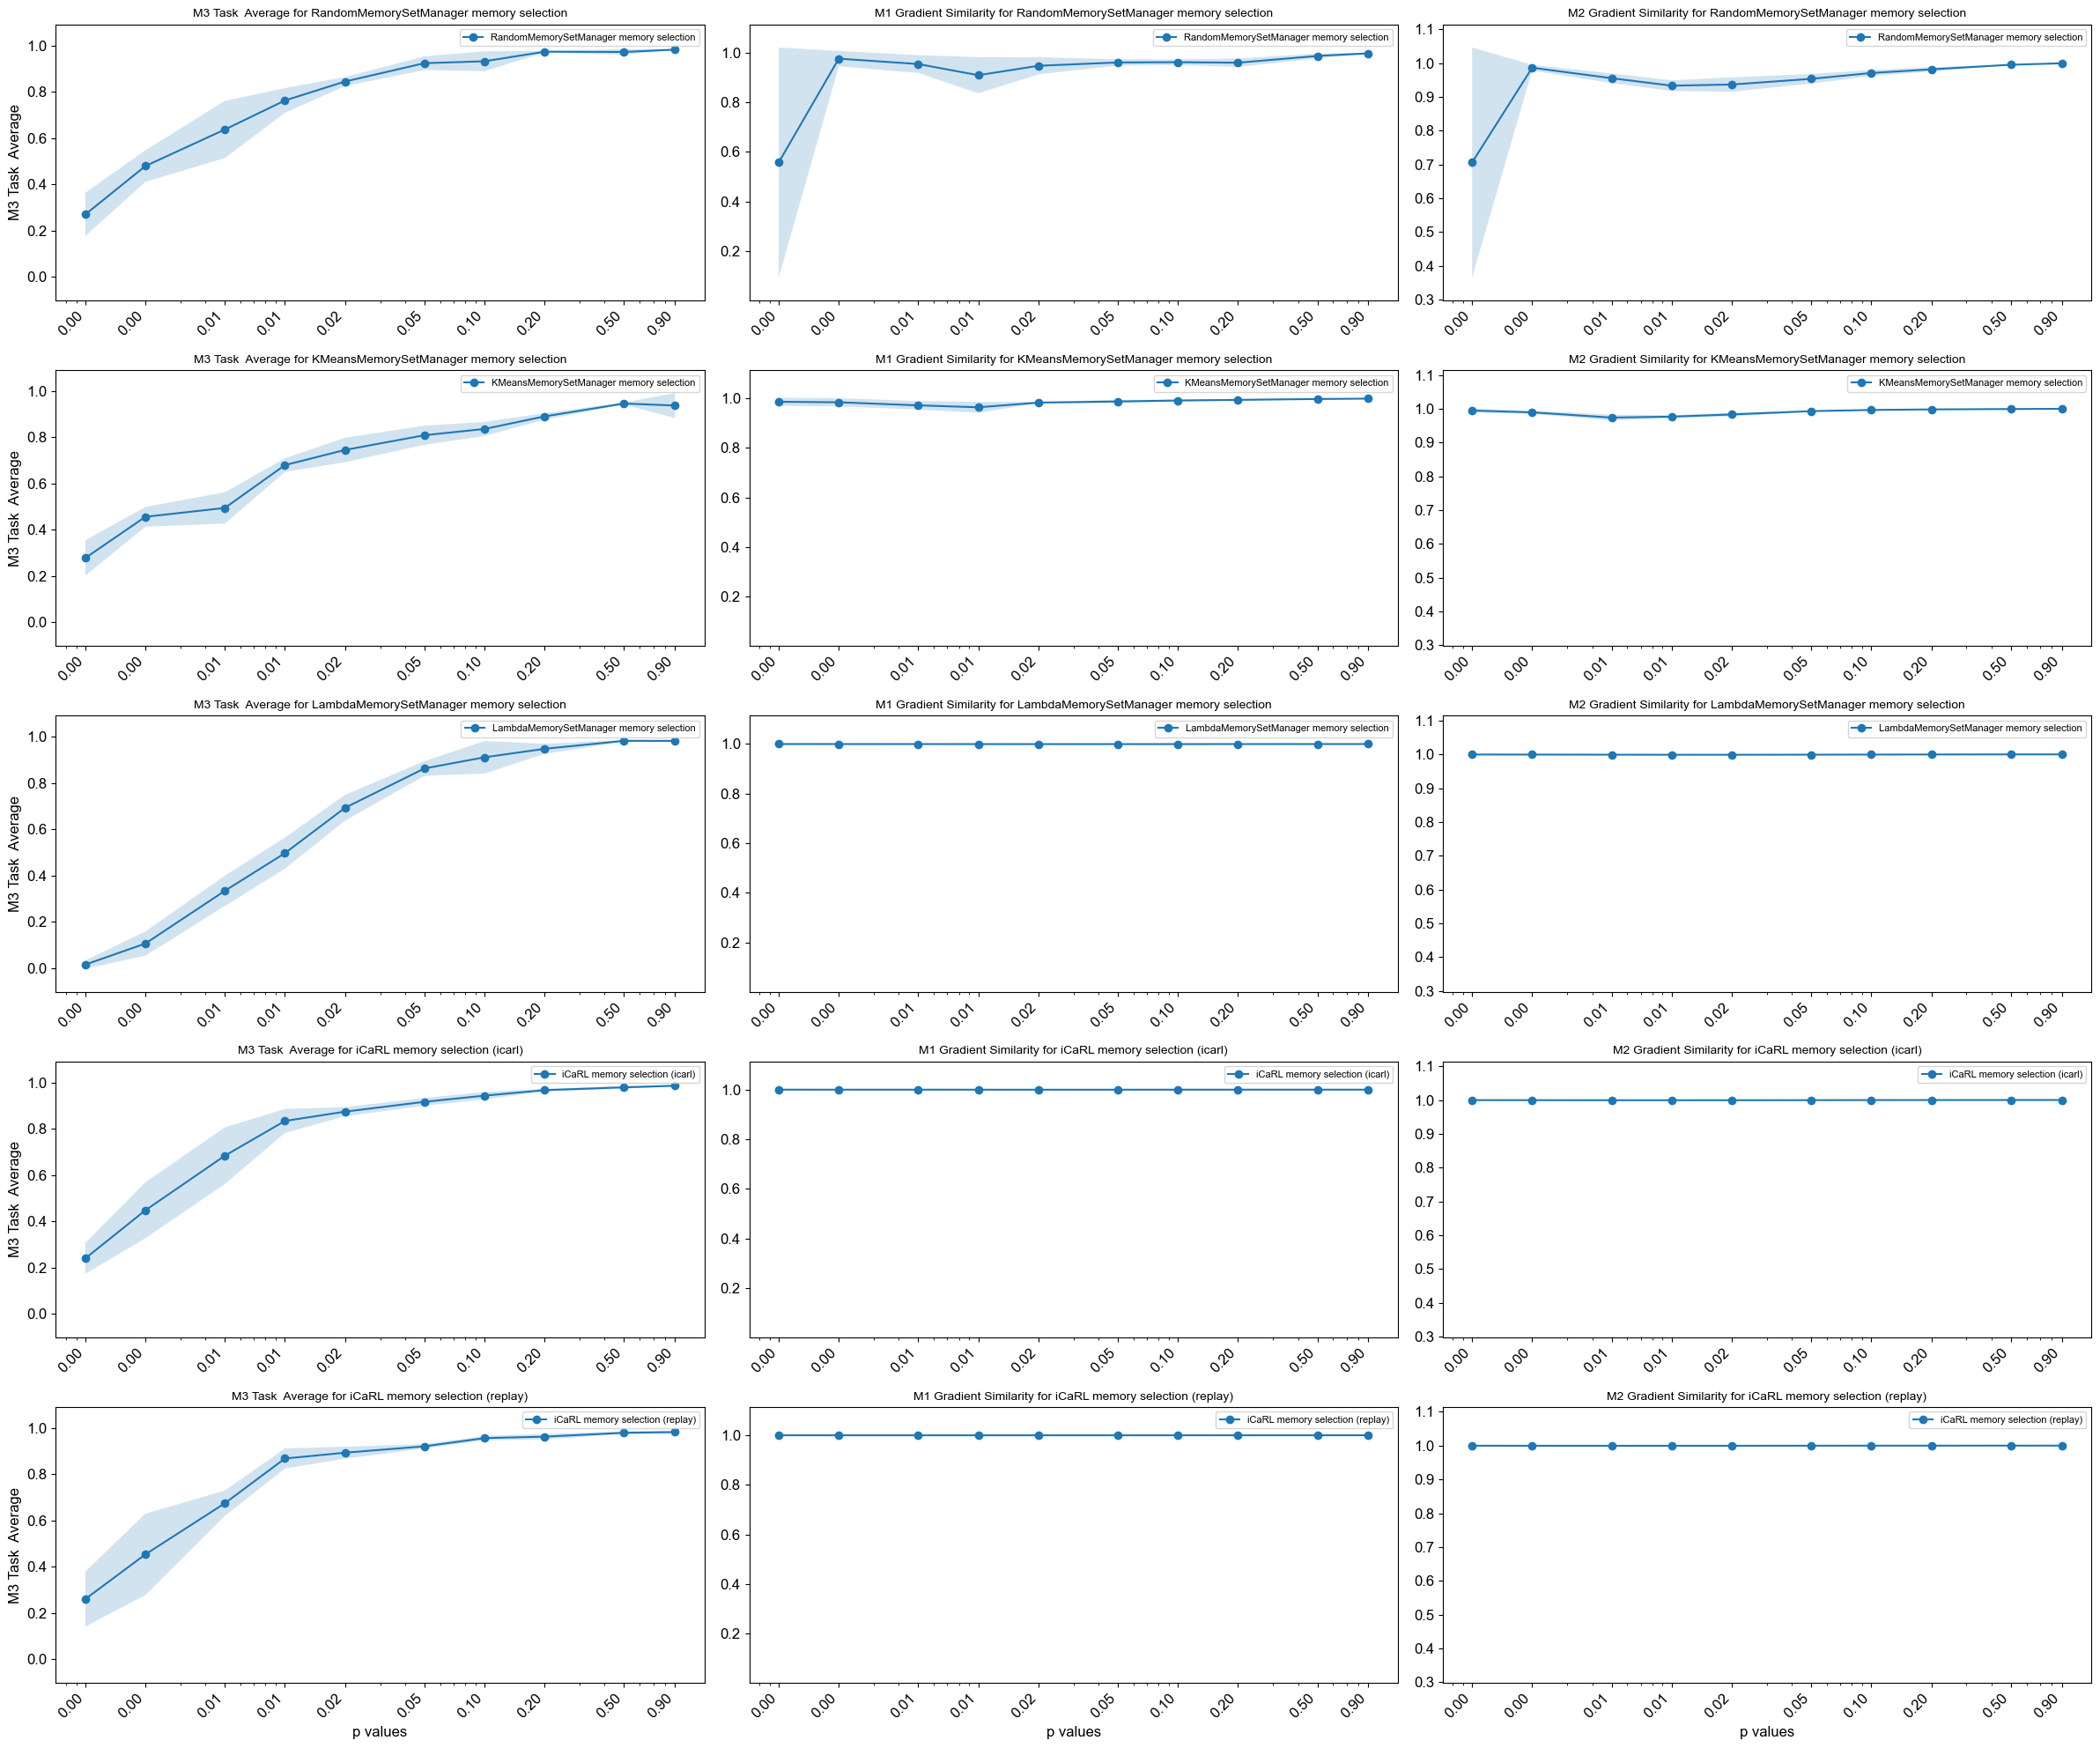

In [98]:
def plot_all_metrics_normalize_axis(aggregated_results, dataset_name):
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 12
    
    result_dir = f'gradient_similarity/{dataset_name}/plots'
    if not os.path.exists(result_dir):
        os.makedirs(result_dir)
    
    methods = aggregated_results['method'].unique()
    p_vals = sorted(aggregated_results['p'].unique())
    
    num_methods = len(methods)
    fig, axs = plt.subplots(num_methods, 3, figsize=(24, 4*num_methods))
    
    metrics = ['M3_task', 'M1_grad_sim', 'M2_grad_sim']
    titles = ['M3 Task  Average', 'M1 Gradient Similarity', 'M2 Gradient Similarity']
    
    # Find global min and max for each metric, including std
    y_limits = {}
    for metric in metrics:
        min_val = (aggregated_results[f'{metric}_avg'] - aggregated_results[f'{metric}_std']).min()
        max_val = (aggregated_results[f'{metric}_avg'] + aggregated_results[f'{metric}_std']).max()
        y_range = max_val - min_val
        y_limits[metric] = (min_val - 0.1 * y_range, max_val + 0.1 * y_range)
    
    for method_index, method in enumerate(methods):
        method_data = aggregated_results[aggregated_results['method'] == method]
        
        for col, (metric, title) in enumerate(zip(metrics, titles)):
            if num_methods == 1:
                ax = axs[col]
            else:
                ax = axs[method_index, col]
            
            avg_values = [method_data[method_data['p'] == p][f'{metric}_avg'].values[0] for p in p_vals]
            std_values = [method_data[method_data['p'] == p][f'{metric}_std'].values[0] for p in p_vals]
            
            ax.plot(p_vals, avg_values, marker='o', label=method)
            ax.fill_between(p_vals, 
                            np.array(avg_values) - np.array(std_values), 
                            np.array(avg_values) + np.array(std_values), 
                            alpha=0.2)
            
            ax.set_xscale('log')
            ax.set_title(f'{title} for {method}', fontsize=10)
            ax.legend(fontsize=8)
            
            ax.set_xticks(p_vals)
            ax.set_xticklabels([f'{p:.2f}' for p in p_vals], rotation=45, ha='right')
            
            # Set y-axis limits to be the same for all methods within each metric
            ax.set_ylim(y_limits[metric])
            
            if method_index == num_methods - 1:  # Last row
                ax.set_xlabel('p values')
            
            if col == 0:  # First column
                ax.set_ylabel(title)
    
    plt.tight_layout()
    plt.savefig(f'{result_dir}/all_metrics_vs_p_subplots.png')
    plt.show()

plot_all_metrics_normalize_axis(aggregated_results, 'dataset_name')

KeyError: 'M3_task_array'

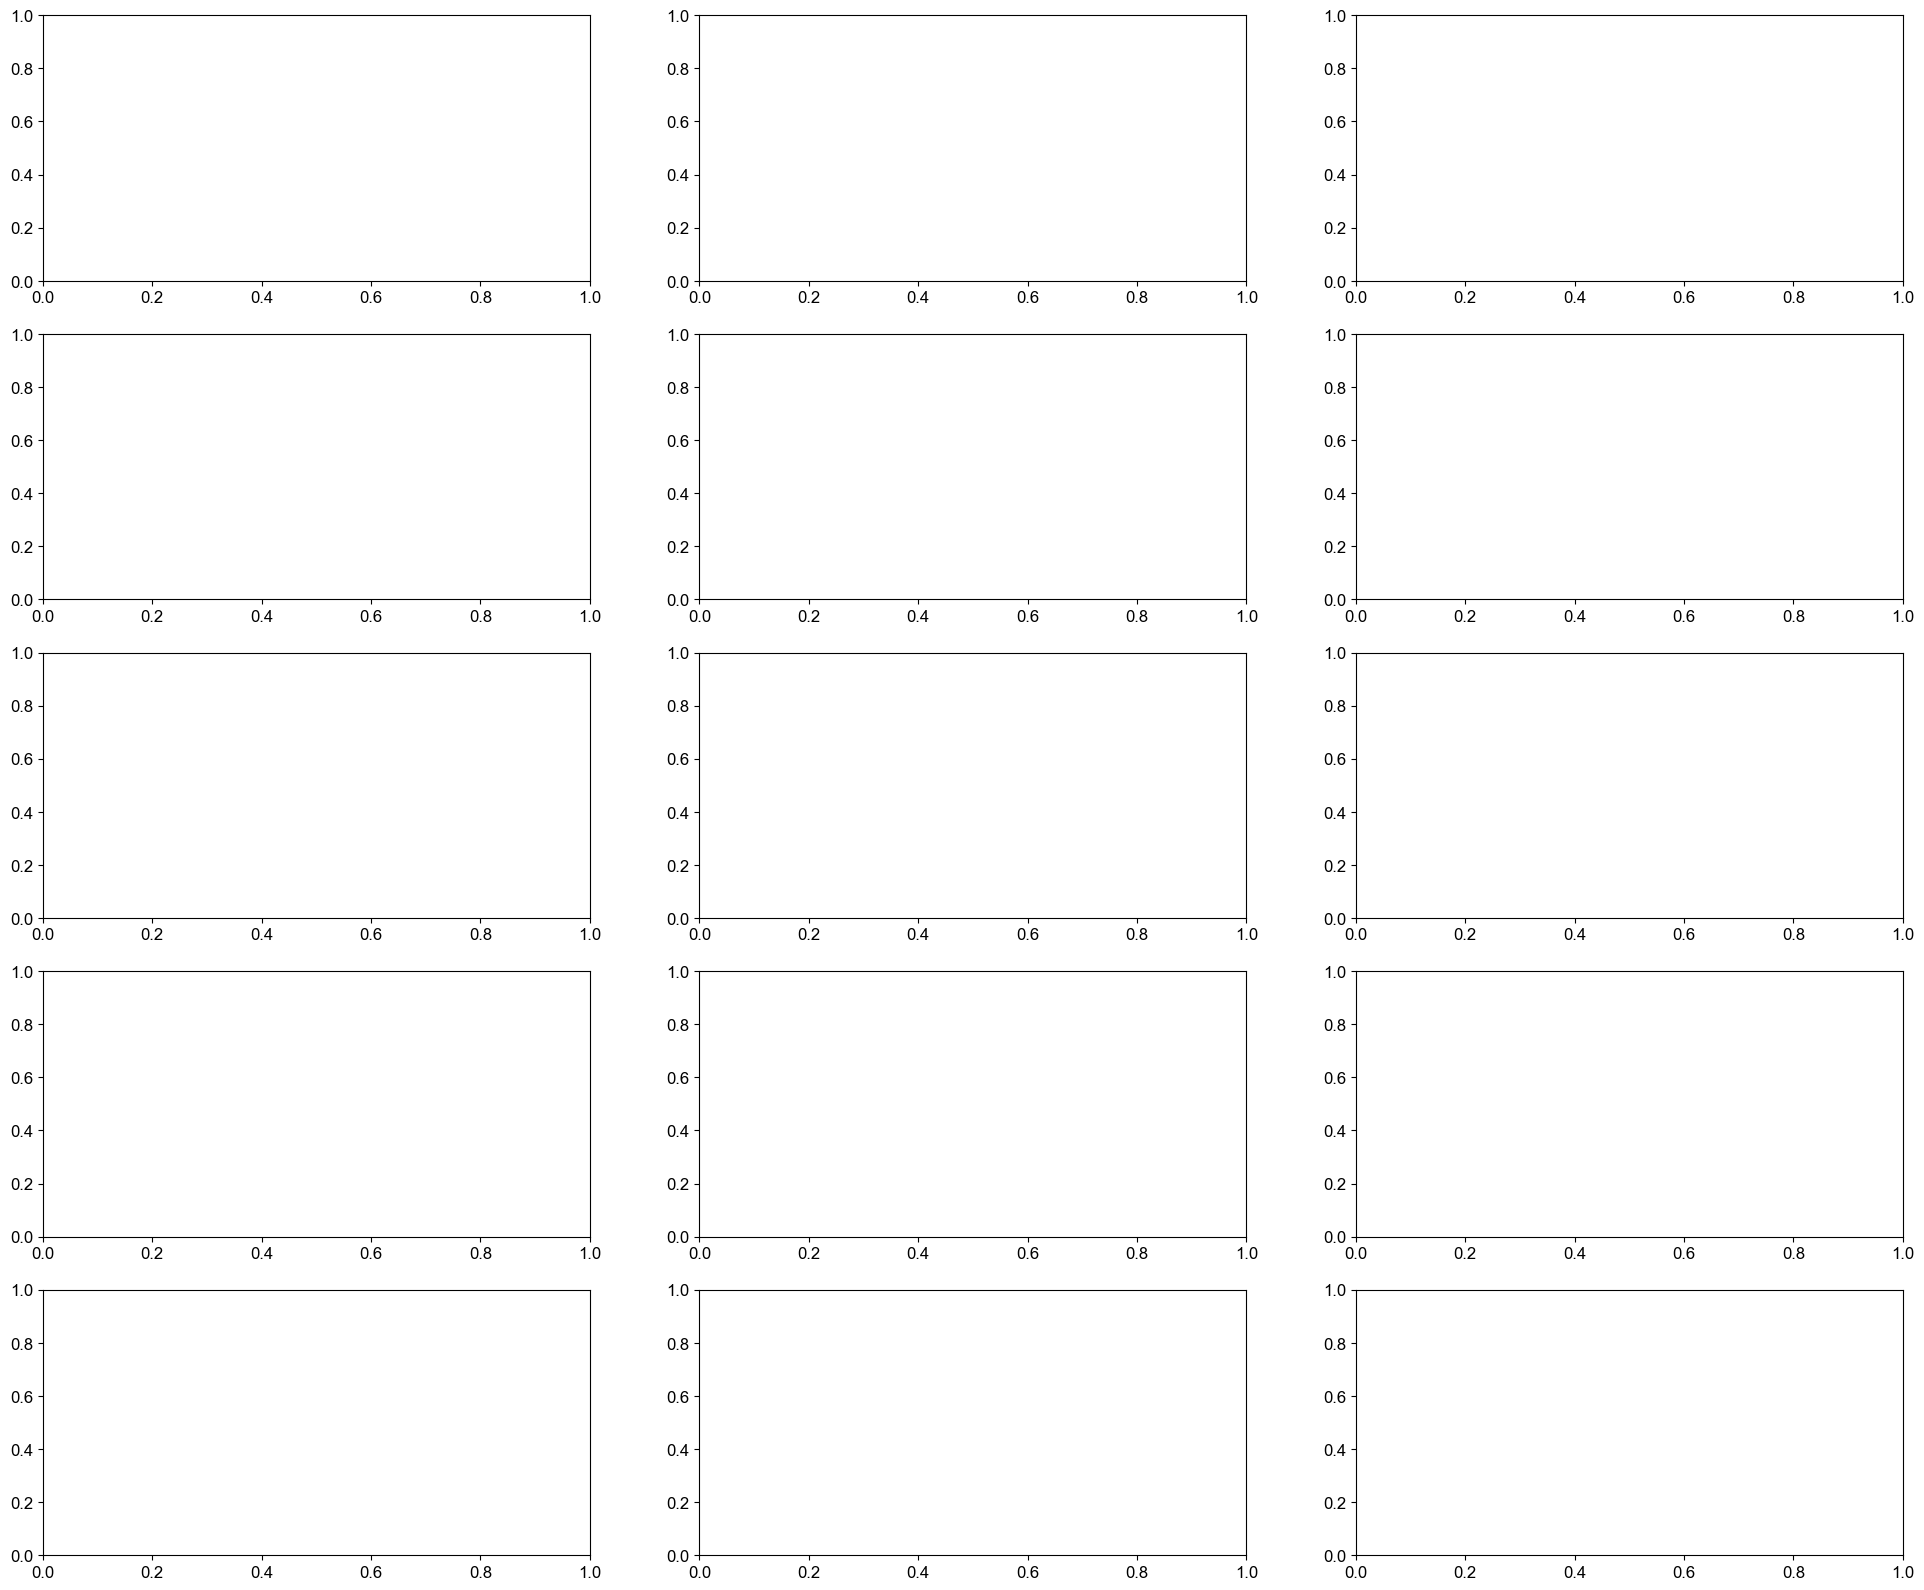

In [99]:
def plot_all_metrics(aggregated_results, dataset_name):
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 12
    
    result_dir = f'gradient_similarity/{dataset_name}/plots'
    if not os.path.exists(result_dir):
        os.makedirs(result_dir)
    
    methods = aggregated_results['method'].unique()
    p_vals = sorted(aggregated_results['p'].unique())
    
    num_methods = len(methods)
    fig, axs = plt.subplots(num_methods, 3, figsize=(24, 4*num_methods))
    
    metrics = ['M3_task', 'M1_grad_sim', 'M2_grad_sim']
    titles = [f'M3 Task {task_no} Accuracy', 'M1 Gradient Similarity', 'M2 Gradient Similarity']
    
    for method_index, method in enumerate(methods):
        method_data = aggregated_results[aggregated_results['method'] == method]
        
        for col, (metric, title) in enumerate(zip(metrics, titles)):
            if num_methods == 1:
                ax = axs[col]
            else:
                ax = axs[method_index, col]
            
            # Get the number of samples
            num_samples = len(method_data[method_data['p'] == p_vals[0]][f'{metric}_array'].values[0])
            
            for sample_index in range(num_samples):
                sample_values = [method_data[method_data['p'] == p][f'{metric}_array'].values[0][sample_index] for p in p_vals]
                ax.plot(p_vals, sample_values, alpha=0.3, linewidth=1)
            
            # Calculate and plot the mean
            mean_values = [np.mean(method_data[method_data['p'] == p][f'{metric}_array'].values[0]) for p in p_vals]
            ax.plot(p_vals, mean_values, color='red', linewidth=2, label='Mean')
            
            ax.set_xscale('log')
            ax.set_title(f'{title} for {method}', fontsize=10)
            ax.legend(fontsize=8)
            
            ax.set_xticks(p_vals)
            ax.set_xticklabels([f'{p:.2f}' for p in p_vals], rotation=45, ha='right')
            
            if method_index == num_methods - 1:  # Last row
                ax.set_xlabel('p values')
            
            if col == 0:  # First column
                ax.set_ylabel(title)
    
    plt.tight_layout()
    plt.savefig(f'{result_dir}/all_metrics_vs_p_subplots_sample_lines.png')
    plt.show()

plot_all_metrics(aggregated_results, 'dataset_name')

In [ ]:
#ENDDD

In [ ]:
def aggregate_results(results):
    #get method names
    colnames = results.columns

    # Convert to list if it's an Index object
    colnames_list = colnames.tolist()

    try:
        # First, try to find 'execution_time'
        execution_time_index = colnames_list.index('execution_time')
    except ValueError:
        try:
            # If 'execution_time' is not found, look for 'p'
            execution_time_index = colnames_list.index('p')
        except ValueError:
            # If neither is found, use all column names
            execution_time_index = len(colnames_list)

    methods = colnames_list[:execution_time_index]
    method_names = methods

    unique_p_values = results['p'].unique()

    # Find the minimum number of samples across all p-values and methods
    min_samples = float('inf')
    for p in unique_p_values:
        for method in methods:
            filtered_data = results[(results['p'] == p) & (results[method].notna())]
            # print(method)
            # print(p)
            # print(min_samples)
            # print(len(filtered_data))

            min_samples = min(min_samples, len(filtered_data))

    # Initialize a list to store the processed data
    processed_data = []

    for p in unique_p_values:
        for method, method_name in zip(methods, method_names):
            # Filter data for current p and method
            filtered_data = results[(results['p'] == p) & (results[method].notna())]
            
            if not filtered_data.empty:
                # Select the first min_samples rows
                filtered_data = filtered_data.head(min_samples)

                # Extract and process the data
                m3_task_performances = []
                m1_grad_sims = []
                m2_grad_sims = []
                
                for cell in filtered_data[method]:
                    m3_task_performances.append(cell['M3 per task performance'][task_no])
                    m1_grad_sims.append(cell['gradient similarities']['M1'])
                    m2_grad_sims.append(cell['gradient similarities']['M2'])
                
                # Calculate averages and standard deviations
                m3_avg, m3_std = np.mean(m3_task_performances), np.std(m3_task_performances)
                m1_avg, m1_std = np.mean(m1_grad_sims), np.std(m1_grad_sims)
                m2_avg, m2_std = np.mean(m2_grad_sims), np.std(m2_grad_sims)
                
                # Append to processed data
                processed_data.append({
                    'p': p,
                    'method': method_name,
                    'samples': min_samples,
                    'M3_task_avg': m3_avg,
                    'M3_task_std': m3_std,
                    'M1_grad_sim_avg': m1_avg,
                    'M1_grad_sim_std': m1_std,
                    'M2_grad_sim_avg': m2_avg,
                    'M2_grad_sim_std': m2_std
                })

    # Create a new DataFrame with the processed data
    processed_df = pd.DataFrame(processed_data)
    
    return processed_df

In [ ]:
aggregated_results = aggregate_results(results)
aggregated_results

In [ ]:
def plot_all_metrics(aggregated_results, dataset_name):
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 12
    
    result_dir = f'gradient_similarity/{dataset_name}/plots'
    if not os.path.exists(result_dir):
        os.makedirs(result_dir)
    
    methods = aggregated_results['method'].unique()
    p_vals = sorted(aggregated_results['p'].unique())
    
    num_methods = len(methods)
    fig, axs = plt.subplots(num_methods, 3, figsize=(24, 4*num_methods))
    
    metrics = ['M3_task', 'M1_grad_sim', 'M2_grad_sim']
    titles = [f'M3 Task {task_no} Average Accuracy', 'M1 Gradient Similarity', 'M2 Gradient Similarity']
    
    for method_index, method in enumerate(methods):
        method_data = aggregated_results[aggregated_results['method'] == method]
        
        for col, (metric, title) in enumerate(zip(metrics, titles)):
            if num_methods == 1:
                ax = axs[col]
            else:
                ax = axs[method_index, col]
            
            avg_values = [method_data[method_data['p'] == p][f'{metric}_avg'].values[0] for p in p_vals]
            std_values = [method_data[method_data['p'] == p][f'{metric}_std'].values[0] for p in p_vals]
            
            ax.plot(p_vals, avg_values, marker='o', label=method)
            ax.fill_between(p_vals, 
                            np.array(avg_values) - np.array(std_values), 
                            np.array(avg_values) + np.array(std_values), 
                            alpha=0.2)
            
            ax.set_xscale('log')
            ax.set_title(f'{title} for {method}', fontsize=10)
            ax.legend(fontsize=8)
            
            ax.set_xticks(p_vals)
            ax.set_xticklabels([f'{p:.2f}' for p in p_vals], rotation=45, ha='right')
            
            if method_index == num_methods - 1:  # Last row
                ax.set_xlabel('p values')
            
            if col == 0:  # First column
                ax.set_ylabel(title)
    
    plt.tight_layout()
    plt.savefig(f'{result_dir}/all_metrics_vs_p_subplots.png')
    plt.show()

plot_all_metrics(aggregated_results, 'dataset_name')

In [ ]:

def plot_all_metrics_normalize_axis(aggregated_results, dataset_name):
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 12
    
    result_dir = f'gradient_similarity/{dataset_name}/plots'
    if not os.path.exists(result_dir):
        os.makedirs(result_dir)
    
    methods = aggregated_results['method'].unique()
    p_vals = sorted(aggregated_results['p'].unique())
    
    num_methods = len(methods)
    fig, axs = plt.subplots(num_methods, 3, figsize=(24, 4*num_methods))
    
    metrics = ['M3_task', 'M1_grad_sim', 'M2_grad_sim']
    titles = [f'M3 Task {task_no} Average', 'M1 Gradient Similarity', 'M2 Gradient Similarity']
    
    # Find global min and max for each metric, including std
    y_limits = {}
    for metric in metrics:
        min_val = (aggregated_results[f'{metric}_avg'] - aggregated_results[f'{metric}_std']).min()
        max_val = (aggregated_results[f'{metric}_avg'] + aggregated_results[f'{metric}_std']).max()
        y_range = max_val - min_val
        y_limits[metric] = (min_val - 0.1 * y_range, max_val + 0.1 * y_range)
    
    for method_index, method in enumerate(methods):
        method_data = aggregated_results[aggregated_results['method'] == method]
        
        for col, (metric, title) in enumerate(zip(metrics, titles)):
            if num_methods == 1:
                ax = axs[col]
            else:
                ax = axs[method_index, col]
            
            avg_values = [method_data[method_data['p'] == p][f'{metric}_avg'].values[0] for p in p_vals]
            std_values = [method_data[method_data['p'] == p][f'{metric}_std'].values[0] for p in p_vals]
            
            ax.plot(p_vals, avg_values, marker='o', label=method)
            ax.fill_between(p_vals, 
                            np.array(avg_values) - np.array(std_values), 
                            np.array(avg_values) + np.array(std_values), 
                            alpha=0.2)
            
            ax.set_xscale('log')
            ax.set_title(f'{title} for {method}', fontsize=10)
            ax.legend(fontsize=8)
            
            ax.set_xticks(p_vals)
            ax.set_xticklabels([f'{p:.2f}' for p in p_vals], rotation=45, ha='right')
            
            # Set y-axis limits to be the same for all methods within each metric
            ax.set_ylim(y_limits[metric])
            
            if method_index == num_methods - 1:  # Last row
                ax.set_xlabel('p values')
            
            if col == 0:  # First column
                ax.set_ylabel(title)
    
    plt.tight_layout()
    plt.savefig(f'{result_dir}/all_metrics_vs_p_subplots.png')
    plt.show()

plot_all_metrics_normalize_axis(aggregated_results, 'dataset_name')